In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df0=pd.read_csv('/content/drive/MyDrive/Pandas/mushrooms.csv') #initially, for EDA
df=pd.read_csv('/content/drive/MyDrive/Pandas/mushrooms.csv') #main

#**EDA**

In [ ]:
# Check the rows
df0

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [ ]:
# Check basic info
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [ ]:
# Summary of all categorical features
df0.describe(include='object')

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [ ]:
#Target/class Distribution (Pie Chart & Bar Chart)
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Count of edible vs poisonous
print(df0['class'].value_counts())

class
e    4208
p    3916
Name: count, dtype: int64


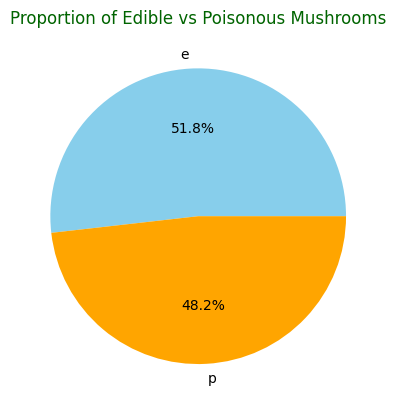

In [ ]:
# Pie chart for edible vs poisonous
df0['class'].value_counts().plot(kind='pie', autopct='%0.1f%%', colors=['skyblue', 'orange'])
plt.title("Proportion of Edible vs Poisonous Mushrooms",color="darkgreen")
plt.ylabel('')
plt.show()

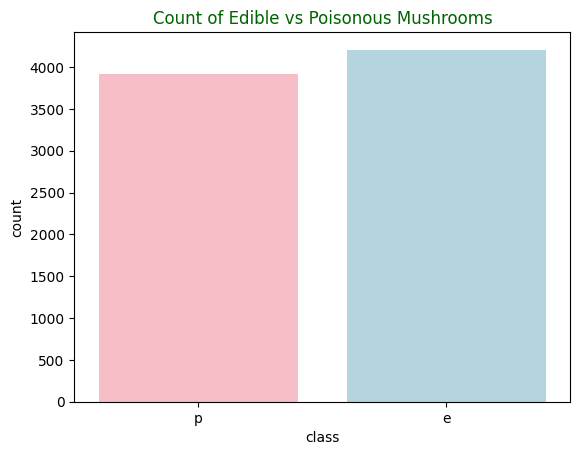

In [ ]:
# Bar chart for target
sns.countplot(x='class', data=df0,hue='class', palette=['lightpink', 'lightblue'])
plt.title("Count of Edible vs Poisonous Mushrooms",color="darkgreen")
plt.show()

**UNIVARIATE ANALYSIS**

Total features (excluding 'class'): 22


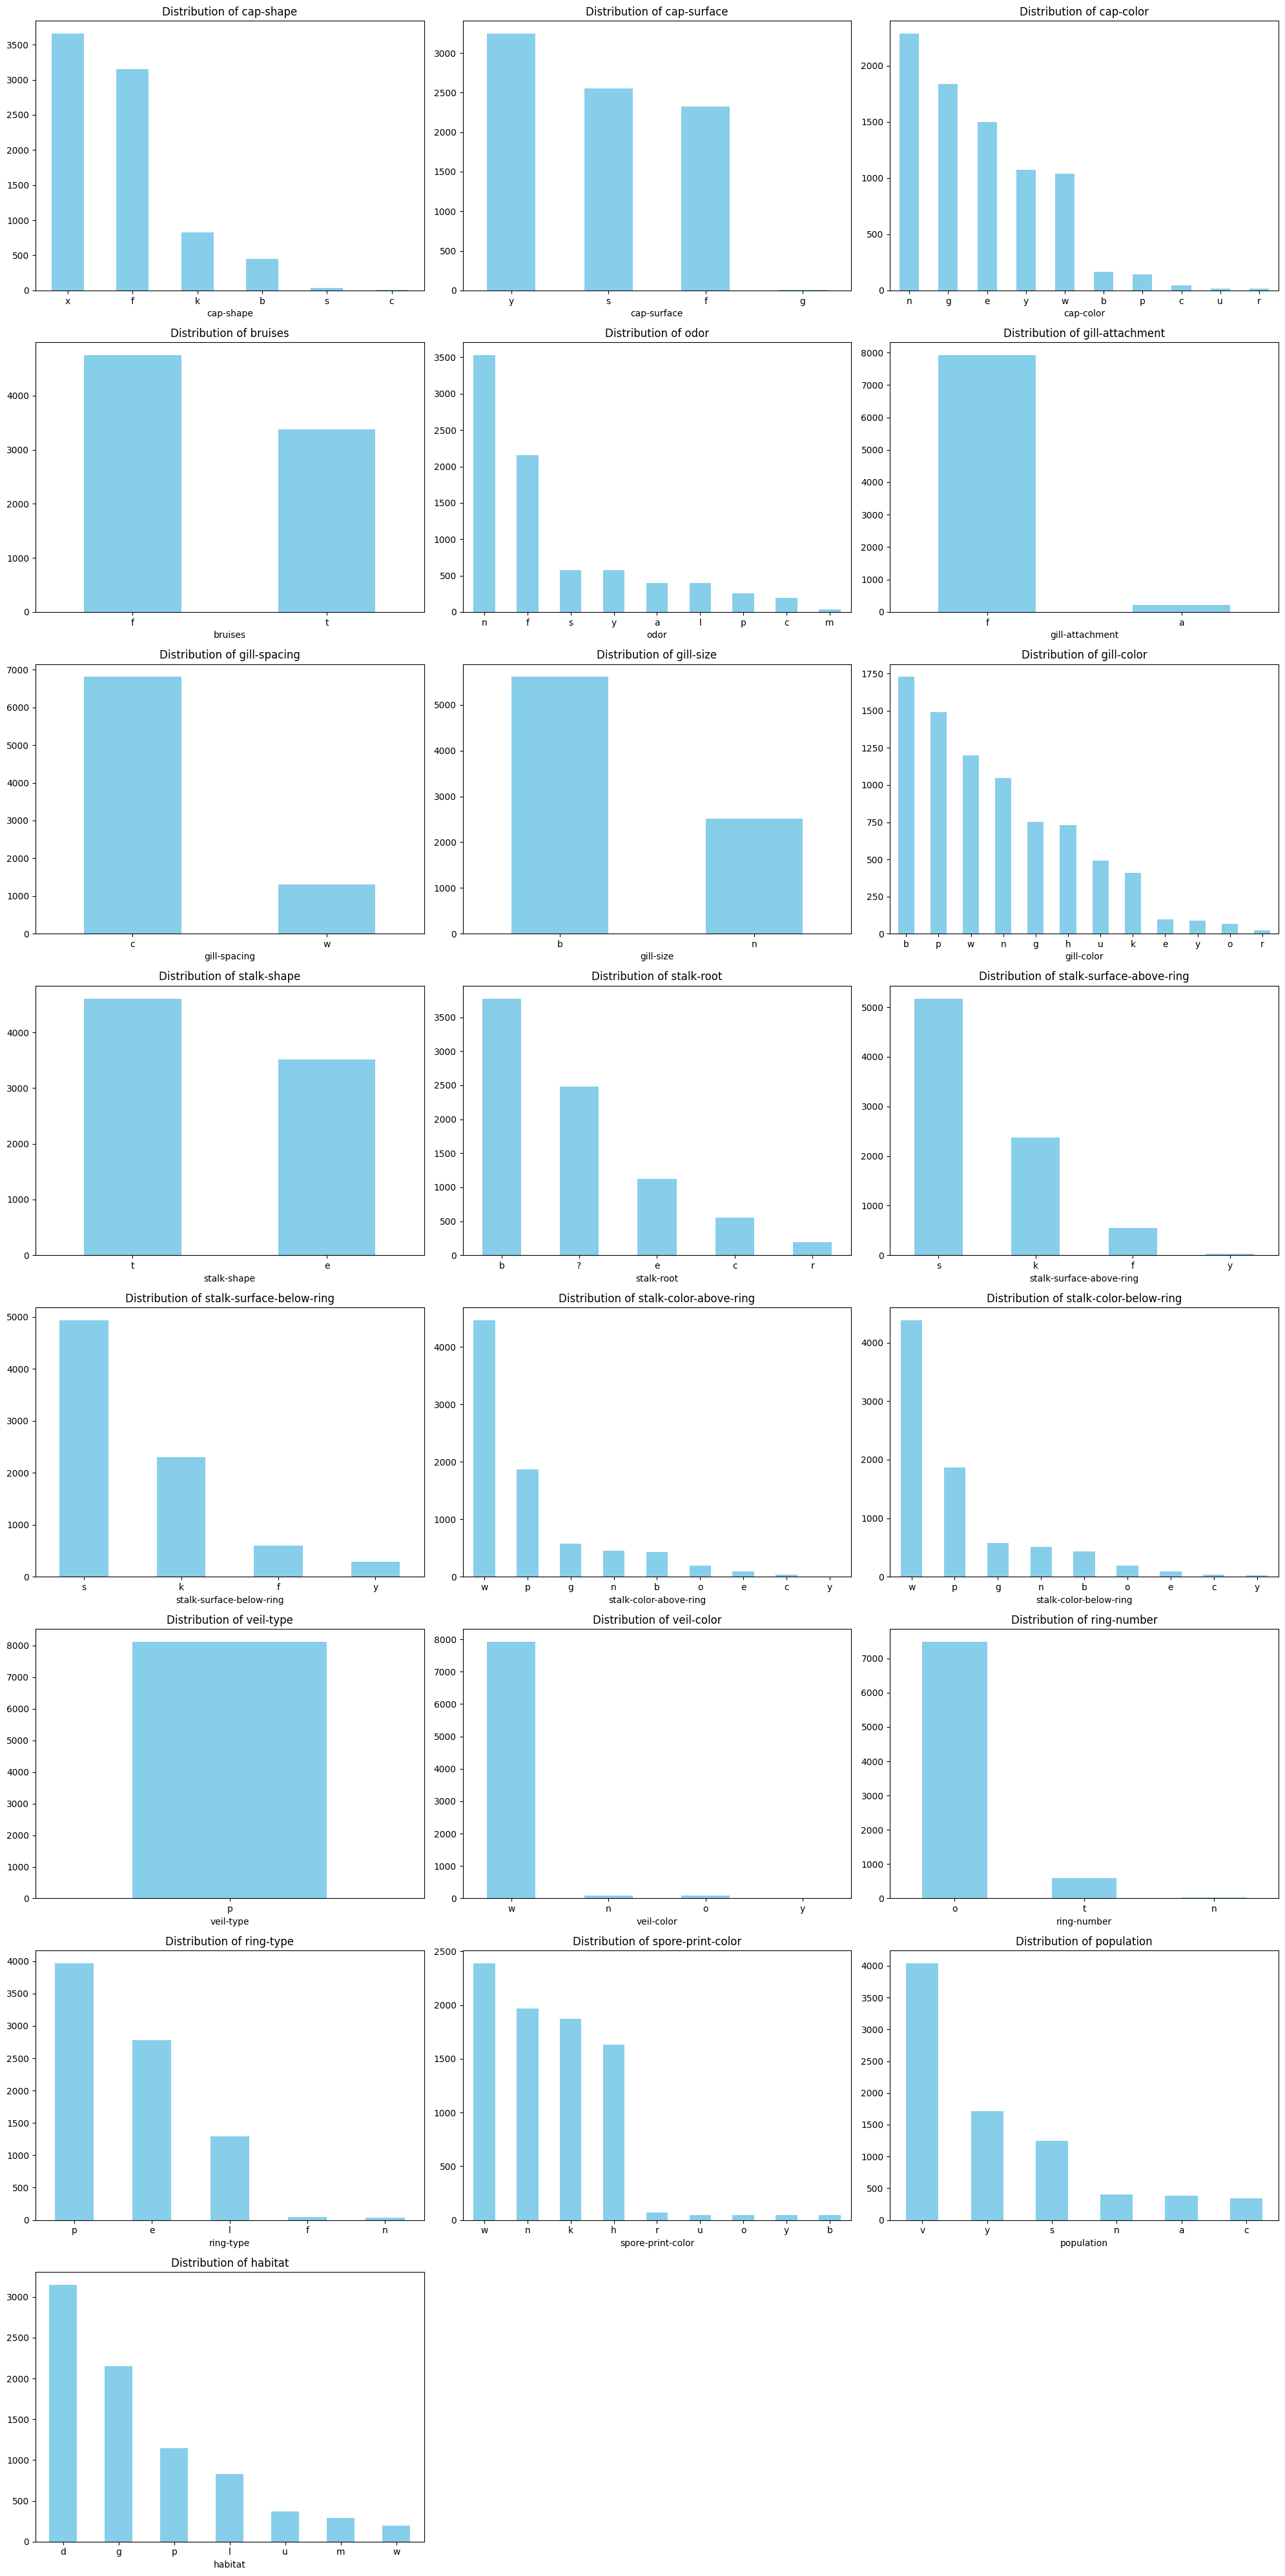

In [ ]:
#UNIVARIATE ANALYSIS

categorical_columns = [col for col in df0.columns.tolist() if col != 'class']
num_features = len(categorical_columns)

print(f"Total features (excluding 'class'): {num_features}")

# Calculate proper grid size
import math
cols = 3
rows = math.ceil(num_features / cols)


fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
axes = axes.ravel()


for i, column in enumerate(categorical_columns):
    df0[column].value_counts().plot(kind='bar', ax=axes[i],color='skyblue')
    axes[i].set_title(f'Distribution of {column}')
    axes[i].tick_params(axis='x', rotation=False)


# Hide any empty subplots
for j in range(num_features, len(axes)):
   axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**BIVARIATE ANALYSIS**

Features to be plotted: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
Total features: 22


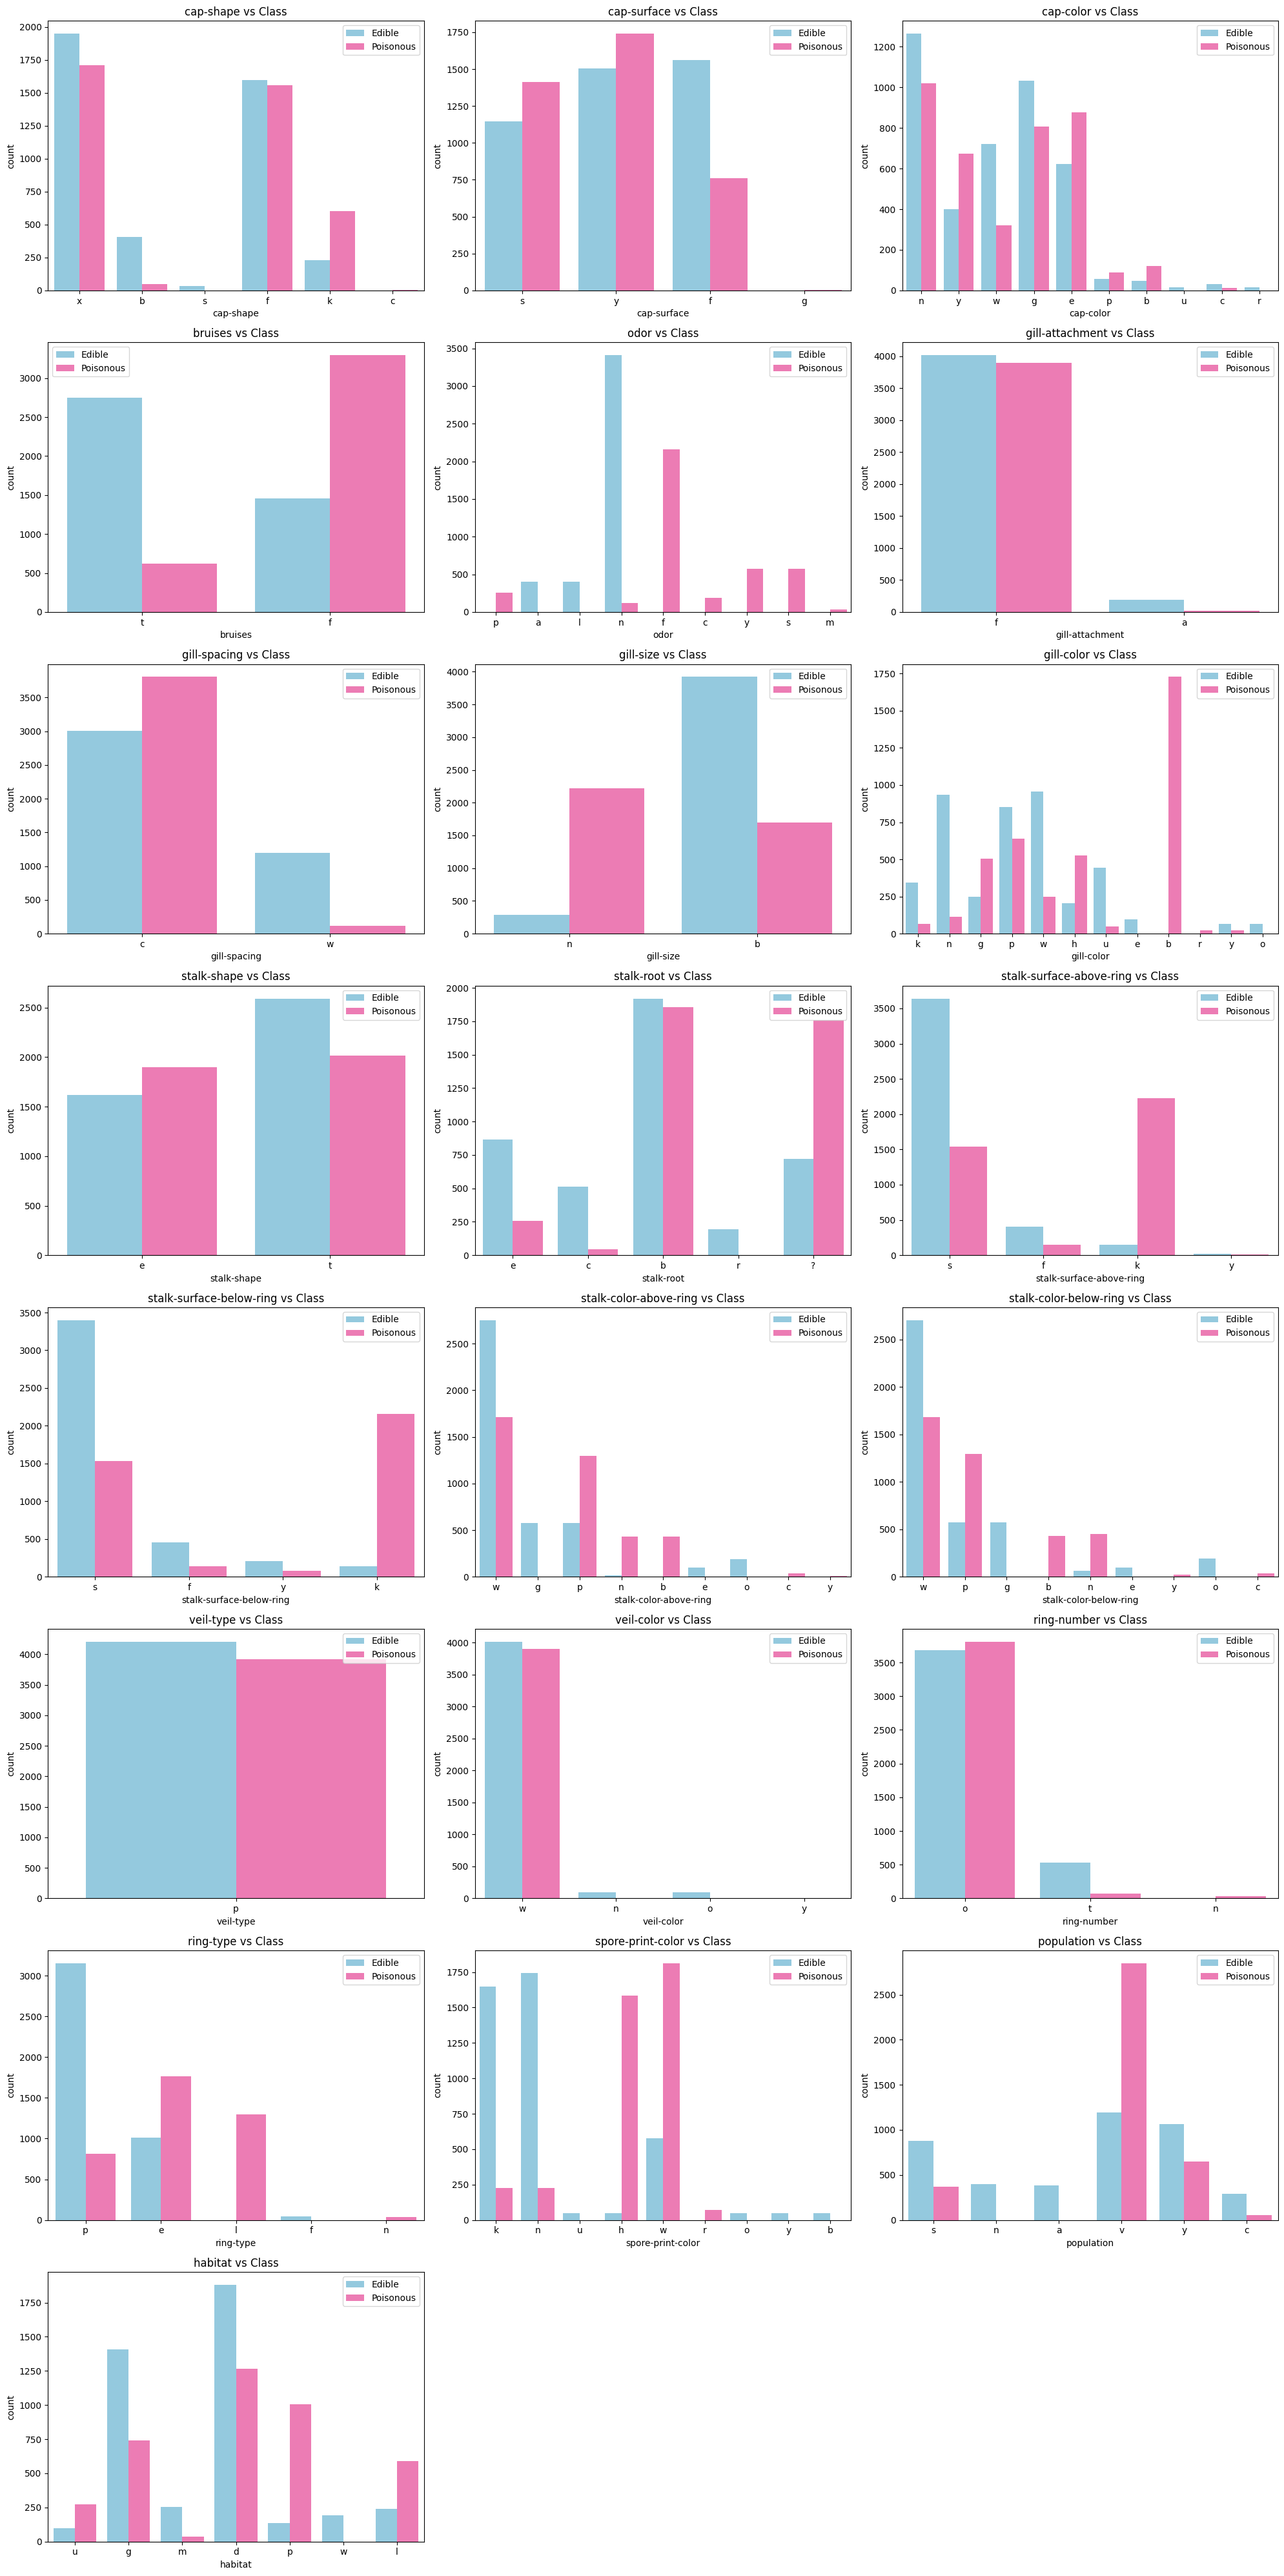

In [ ]:
#Bivariate Analysis (Each Feature vs Target)

# Get ALL feature columns
features = [col for col in df0.columns if col != 'class']

print("Features to be plotted:", features)
print("Total features:", len(features))

# Create subplots
num_features = len(features)
cols=3
rows = math.ceil(num_features / cols)
fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
axes = axes.ravel()

for i, feature in enumerate(features):
    sns.countplot(x=feature, hue='class', data=df0, palette=['skyblue', 'hotpink'], hue_order=['e', 'p'], ax=axes[i])
    axes[i].set_title(f"{feature} vs Class")
    axes[i].tick_params(axis='x', rotation=False)
    axes[i].legend(['Edible', 'Poisonous'])

# Hide any empty subplots if needed
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**ASSOCIATION ANALYSIS**

In [ ]:
#CHI-SQUARE

from scipy.stats import chi2_contingency

chi_square_results = []

# Loop through all features except the target
for col in df0.columns.drop('class'):

    # Check if feature has more than 1 unique value
    if df0[col].nunique() < 2:
        chi_square_results.append([col, None, None, None, "Not Applicable (Only 1 value)"])
        continue

    # Create contingency table (feature vs class)
    contingency_table = pd.crosstab(df0[col], df0['class'])

    # Perform Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Decide significance (p < 0.05)
    significance = "Significant" if p < 0.05 else "Not Significant"

    chi_square_results.append([col, chi2, p, dof, significance])

# Convert to DataFrame
chi_df = pd.DataFrame(chi_square_results,
                      columns=['Feature', 'Chi-Square', 'P-Value', 'Degrees of Freedom', 'Significance'])

# Sort by Chi-Square value
chi_df = chi_df.sort_values(by='Chi-Square', ascending=False, na_position='last')

chi_df


,Feature,Chi-Square,P-Value,Degrees of Freedom,Significance
4,odor,7659.726740,0.000000e+00,8.0,Significant
19,spore-print-color,4602.033170,0.000000e+00,8.0,Significant
8,gill-color,3765.714086,0.000000e+00,11.0,Significant
18,ring-type,2956.619278,0.000000e+00,4.0,Significant
11,stalk-surface-above-ring,2808.286287,0.000000e+00,3.0,Significant
12,stalk-surface-below-ring,2684.474076,0.000000e+00,3.0,Significant
7,gill-size,2366.834257,0.000000e+00,1.0,Significant
13,stalk-color-above-ring,2237.898496,0.000000e+00,8.0,Significant
14,stalk-color-below-ring,2152.390891,0.000000e+00,8.0,Significant
3,bruises,2041.415647,0.000000e+00,1.0,Significant


/tmp/ipython-input-2944528534.py:16: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((ccorr-1), (rcorr-1)))
/tmp/ipython-input-2944528534.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CramersV', y=cramers_df.index, data=cramers_df, palette='magma')


                          CramersV
odor                      0.970558
spore-print-color         0.752036
gill-color                0.679877
ring-type                 0.602900
stalk-surface-above-ring  0.587666
stalk-surface-below-ring  0.574551
gill-size                 0.539677
stalk-color-above-ring    0.523943
stalk-color-below-ring    0.513799
bruises                   0.501188
population                0.486775
habitat                   0.439323
stalk-root                0.406224
gill-spacing              0.347897
cap-shape                 0.244330
cap-color                 0.215889
ring-number               0.214212
cap-surface               0.195997
veil-color                0.152222
gill-attachment           0.127951
stalk-shape               0.101170
veil-type                      NaN


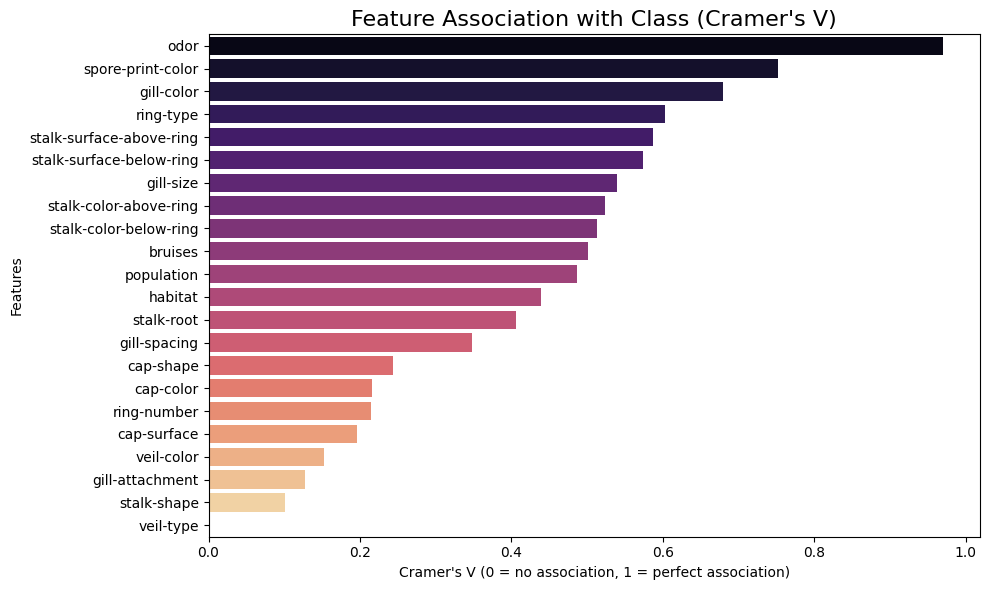

In [ ]:
#CRAMER'S V

import matplotlib.pyplot as plt
import seaborn as sns

# Function to calculate Cramer's V
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2/n
    r, c = contingency_table.shape
    phi2corr = max(0, phi2 - ((c-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    ccorr = c - ((c-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((ccorr-1), (rcorr-1)))

# Calculate Cramer's V for all features vs target
features = df0.columns.drop('class')  #index object
cramers_results = {}

for col in features:
    cramers_results[col] = cramers_v(df0[col], df0['class'])

# Convert to DataFrame and sort
cramers_df = pd.DataFrame.from_dict(cramers_results, orient='index', columns=['CramersV'])
cramers_df = cramers_df.sort_values(by='CramersV', ascending=False)

# Print Cramer's V values
print(cramers_df)

# Bar Chart for Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(x='CramersV', y=cramers_df.index, data=cramers_df, palette='magma')
plt.title("Feature Association with Class (Cramer's V)", fontsize=16)
plt.xlabel("Cramer's V (0 = no association, 1 = perfect association)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

#**DATA PREPROCESSING**

In [ ]:
#DROP veil-type
df = df.drop(columns=['veil-type'])

In [ ]:
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,s,w,w,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,s,w,w,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,s,w,w,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,s,w,w,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,s,w,w,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,s,o,o,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,s,o,o,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,s,o,o,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,s,k,w,w,w,o,e,w,v,l


**HANDLE MISSING VALUES**

In [ ]:
#Option 01:Treat as a Separate Category

# Check for actual nulls
print("Null values before replacement:\n", df.isnull().sum())

# Check the 'stalk-root' values
print("\nValue counts for 'stalk-root' before handling '?':")
print(df['stalk-root'].value_counts())

# Treat '?' as a separate category (keep all rows)
# No replacement needed since '?' is already a category, but can confirm:
df['stalk-root'] = df['stalk-root'].fillna('?')  # safe for consistency

# Verify after replacement
print("\nValue counts for 'stalk-root' after handling '?':")
print(df['stalk-root'].value_counts())

# Confirm total nulls (should be 0)
print("\nTotal null values after handling missing data:\n", df.isnull().sum().sum())


Null values before replacement:
 class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Value counts for 'stalk-root' before handling '?':
stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64

Value counts for 'stalk-root' after handling '?':
stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64

Total null value

In [ ]:
#Option 02: Drop Rows
df_dropped = df.copy()

# Count how many rows have missing stalk-root
missing_count = (df_dropped['stalk-root'] == '?').sum()
print(f"Rows with missing stalk-root: {missing_count}")

# Drop rows where stalk-root is missing
df_dropped = df_dropped[df_dropped['stalk-root'] != '?'].copy()

print(f"Shape after dropping missing stalk-root: {df_dropped.shape}")

Rows with missing stalk-root: 2480
Shape after dropping missing stalk-root: (5644, 22)


**ENCODE CATEGORICAL FEATURES**

In [ ]:
#ON ORIGINAL DATASET
from sklearn.preprocessing import LabelEncoder

# Make a copy of the dataset
df_encoded = df.copy()

# Encode all categorical features including target
for col in df_encoded.columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

df_encoded


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,2,7,7,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,2,7,7,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,2,7,7,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,2,7,7,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,2,7,7,2,1,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0,3,2,4,0,5,0,0,0,11,...,2,2,5,5,1,1,4,0,1,2
8120,0,5,2,4,0,5,0,0,0,11,...,2,2,5,5,0,1,4,0,4,2
8121,0,2,2,4,0,5,0,0,0,5,...,2,2,5,5,1,1,4,0,1,2
8122,1,3,3,4,0,8,1,0,1,0,...,2,1,7,7,2,1,0,7,4,2


In [ ]:
#DROPPED DATASET
# Make a copy of the dataset
df_dropped_encoded = df_dropped.copy()

# Encode all categorical features including target
for col in df_dropped_encoded.columns:
    df_dropped_encoded[col] = LabelEncoder().fit_transform(df_dropped_encoded[col])

df_dropped_encoded

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,2,...,2,2,5,5,0,1,3,1,3,5
1,0,5,2,7,1,0,1,0,0,2,...,2,2,5,5,0,1,3,2,2,1
2,0,0,2,6,1,3,1,0,0,3,...,2,2,5,5,0,1,3,2,2,3
3,1,5,3,6,1,6,1,0,1,3,...,2,2,5,5,0,1,3,1,3,5
4,0,5,2,3,0,5,1,1,0,2,...,2,2,5,5,0,1,0,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7986,0,0,3,4,0,5,1,0,0,7,...,3,3,3,3,0,2,3,5,5,4
8001,0,5,3,4,0,5,1,0,0,7,...,3,3,3,3,0,2,3,5,5,4
8038,0,5,3,3,1,5,1,0,0,7,...,2,2,5,5,0,2,3,5,5,4
8095,1,5,3,1,0,4,1,0,0,8,...,1,3,1,1,0,0,2,5,1,0


**TRAIN-TEST SPLIT**

In [ ]:
#ORIGINAL
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['class'])
y = df_encoded['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)


In [ ]:
X

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,5,2,4,1,6,1,0,1,4,0,...,2,2,7,7,2,1,4,2,3,5
1,5,2,9,1,0,1,0,0,4,0,...,2,2,7,7,2,1,4,3,2,1
2,0,2,8,1,3,1,0,0,5,0,...,2,2,7,7,2,1,4,3,2,3
3,5,3,8,1,6,1,0,1,5,0,...,2,2,7,7,2,1,4,2,3,5
4,5,2,3,0,5,1,1,0,4,1,...,2,2,7,7,2,1,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,3,2,4,0,5,0,0,0,11,0,...,2,2,5,5,1,1,4,0,1,2
8120,5,2,4,0,5,0,0,0,11,0,...,2,2,5,5,0,1,4,0,4,2
8121,2,2,4,0,5,0,0,0,5,0,...,2,2,5,5,1,1,4,0,1,2
8122,3,3,4,0,8,1,0,1,0,1,...,2,1,7,7,2,1,0,7,4,2


In [ ]:
#DROPPED
X = df_dropped_encoded.drop('class', axis=1)
y = df_dropped_encoded['class']

X_train_dropped, X_test_dropped, y_train_dropped, y_test_dropped = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)


**CHECK CLASS IMBALANCE**

Training set class distribution:
 class
0    3366
1    3133
Name: count, dtype: int64

Test set class distribution:
 class
0    842
1    783
Name: count, dtype: int64




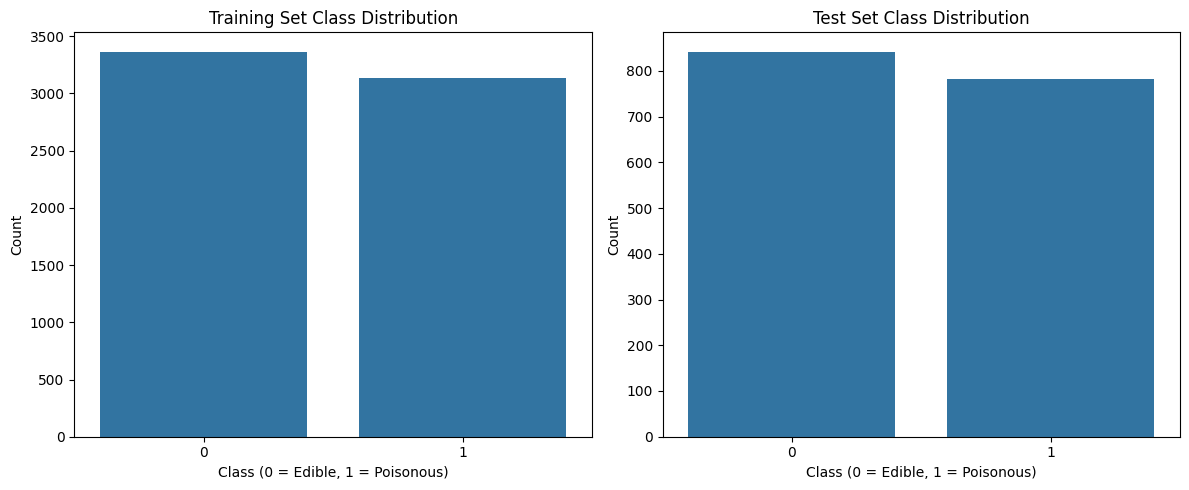

In [ ]:
#ORIGINAL

# Count of each class in training set
print("Training set class distribution:\n", y_train.value_counts())

# Count of each class in test set
print("\nTest set class distribution:\n", y_test.value_counts())

# Visualize with a bar chart
plt.figure(figsize=(12,5))

# Training set
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title("Training Set Class Distribution")
plt.xlabel("Class (0 = Edible, 1 = Poisonous)")
plt.ylabel("Count")

# Test set
plt.subplot(1, 2, 2)
sns.countplot(x=y_test)
plt.title("Test Set Class Distribution")
plt.xlabel("Class (0 = Edible, 1 = Poisonous)")
plt.ylabel("Count")
print("\n")

plt.tight_layout()
plt.show()



Training set class distribution:
 class
0    2790
1    1725
Name: count, dtype: int64

Test set class distribution:
 class
0    698
1    431
Name: count, dtype: int64




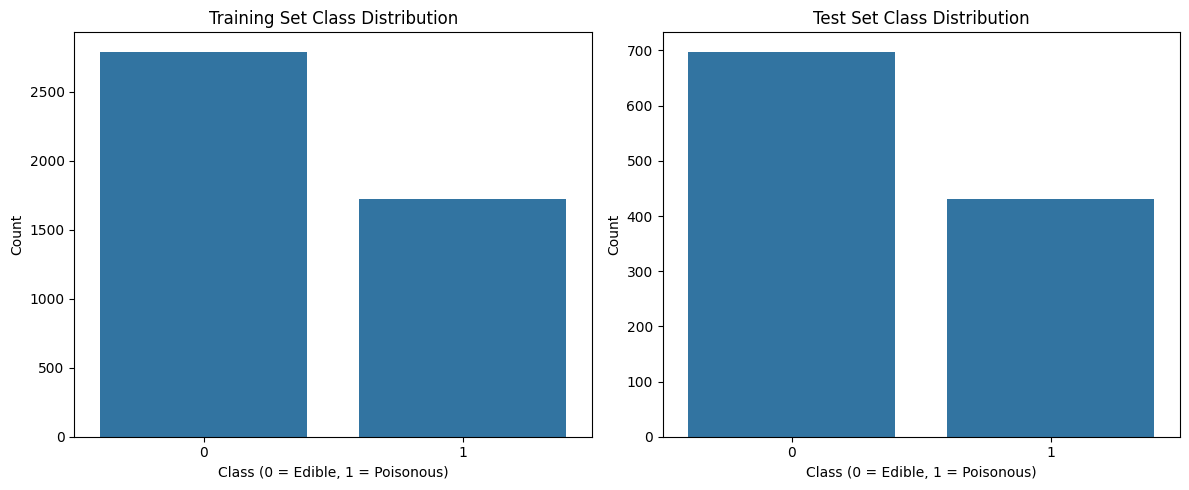

In [ ]:
#Dropped

# Count of each class in training set
print("Training set class distribution:\n", y_train_dropped.value_counts())

# Count of each class in test set
print("\nTest set class distribution:\n", y_test_dropped.value_counts())

# Visualize with a bar chart
plt.figure(figsize=(12,5))

# Training set
plt.subplot(1, 2, 1)
sns.countplot(x=y_train_dropped)
plt.title("Training Set Class Distribution")
plt.xlabel("Class (0 = Edible, 1 = Poisonous)")
plt.ylabel("Count")

# Test set
plt.subplot(1, 2, 2)
sns.countplot(x=y_test_dropped)
plt.title("Test Set Class Distribution")
plt.xlabel("Class (0 = Edible, 1 = Poisonous)")
plt.ylabel("Count")
print("\n")

plt.tight_layout()
plt.show()



**SCALING**

In [ ]:
#ORIGINAL
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled

array([[ 1.01696873,  0.95670486, -0.58891201, ..., -1.09295799,
         0.2747001 , -0.28686745],
       [-0.85252395, -1.46354617, -0.98214525, ..., -0.25324479,
         1.0777932 , -0.8685684 ],
       [-0.85252395, -1.46354617,  1.3772542 , ..., -0.25324479,
         0.2747001 , -0.8685684 ],
       ...,
       [ 1.01696873,  0.95670486, -0.58891201, ..., -1.09295799,
         0.2747001 , -0.8685684 ],
       [ 1.01696873,  0.14995452,  1.3772542 , ...,  1.42618161,
        -1.33148609, -0.28686745],
       [-0.85252395,  0.14995452, -0.58891201, ..., -0.25324479,
        -2.93767228, -0.28686745]])

In [ ]:
# Apply oversampling to training data (only for dropped)
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=1)
X_train_dropped_balanced, y_train_dropped_balanced = ros.fit_resample(X_train_dropped, y_train_dropped)


In [ ]:
#DROPPED
X_train_dropped_scaled = scaler.fit_transform(X_train_dropped_balanced )
X_test_dropped_scaled = scaler.transform(X_test_dropped )

#**FIT MODELS (ORIGINAL DATASET)**

In [ ]:
#FIT NAIVE BAYES
from sklearn.naive_bayes import GaussianNB

# Create model
nb_model = GaussianNB()

# Train
nb_model.fit(X_train_scaled, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test_scaled)


In [ ]:
#FIT SUPPORT VECTOR MACHINE
from sklearn.svm import SVC

# Create model
svm_model = SVC(kernel='rbf', random_state=1)

# Train
svm_model.fit(X_train_scaled, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_scaled)


In [ ]:
#FIT KNN & RANDOM FOREST
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


# Initialize models
knn = KNeighborsClassifier(n_neighbors=3)
rf = RandomForestClassifier(n_estimators=100, random_state=1)

# Fit models
knn.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)


In [ ]:
#FIT FEEDFORWARD NEURAL NETWORK
from sklearn.neural_network import MLPClassifier

# Create model
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # Two hidden layers
    activation='relu',
    solver='adam',#optimization algorithm for weight update during training
    max_iter=300,
    random_state=1
)

# Train
nn_model.fit(X_train_scaled, y_train)

# Predict
y_pred_nn = nn_model.predict(X_test_scaled)


#**EVALUATION (ORIGINAL DATASET)**

In [ ]:
#EVALUATION FUNCTION

def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred,average='macro')
    rec = recall_score(y_true, y_pred,average='macro')
    f1 = f1_score(y_true, y_pred,average='macro')

    # Return metrics and confusion matrix
    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }

In [ ]:
results = {}

results['Naive Bayes'] = evaluate_model(y_test, y_pred_nb, "Naive Bayes")
results['SVM'] = evaluate_model(y_test, y_pred_svm, "Support Vector Machine")
results['KNN'] = evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors")
results['Random Forest'] = evaluate_model(y_test, y_pred_rf, "Random Forest")
results['FNN'] = evaluate_model(y_test, y_pred_nn, "FNN")



In [ ]:
results

{'Naive Bayes': {'model': 'Naive Bayes',
  'accuracy': 0.9236923076923077,
  'precision': 0.9237571157495257,
  'recall': 0.923412600904615,
  'f1': 0.9235623655228713,
  'confusion_matrix': array([[784,  58],
         [ 66, 717]])},
 'SVM': {'model': 'Support Vector Machine',
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'confusion_matrix': array([[842,   0],
         [  0, 783]])},
 'KNN': {'model': 'K-Nearest Neighbors',
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'confusion_matrix': array([[842,   0],
         [  0, 783]])},
 'Random Forest': {'model': 'Random Forest',
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'confusion_matrix': array([[842,   0],
         [  0, 783]])},
 'FNN': {'model': 'FNN',
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'confusion_matrix': array([[842,   0],
         [  0, 783]])}}

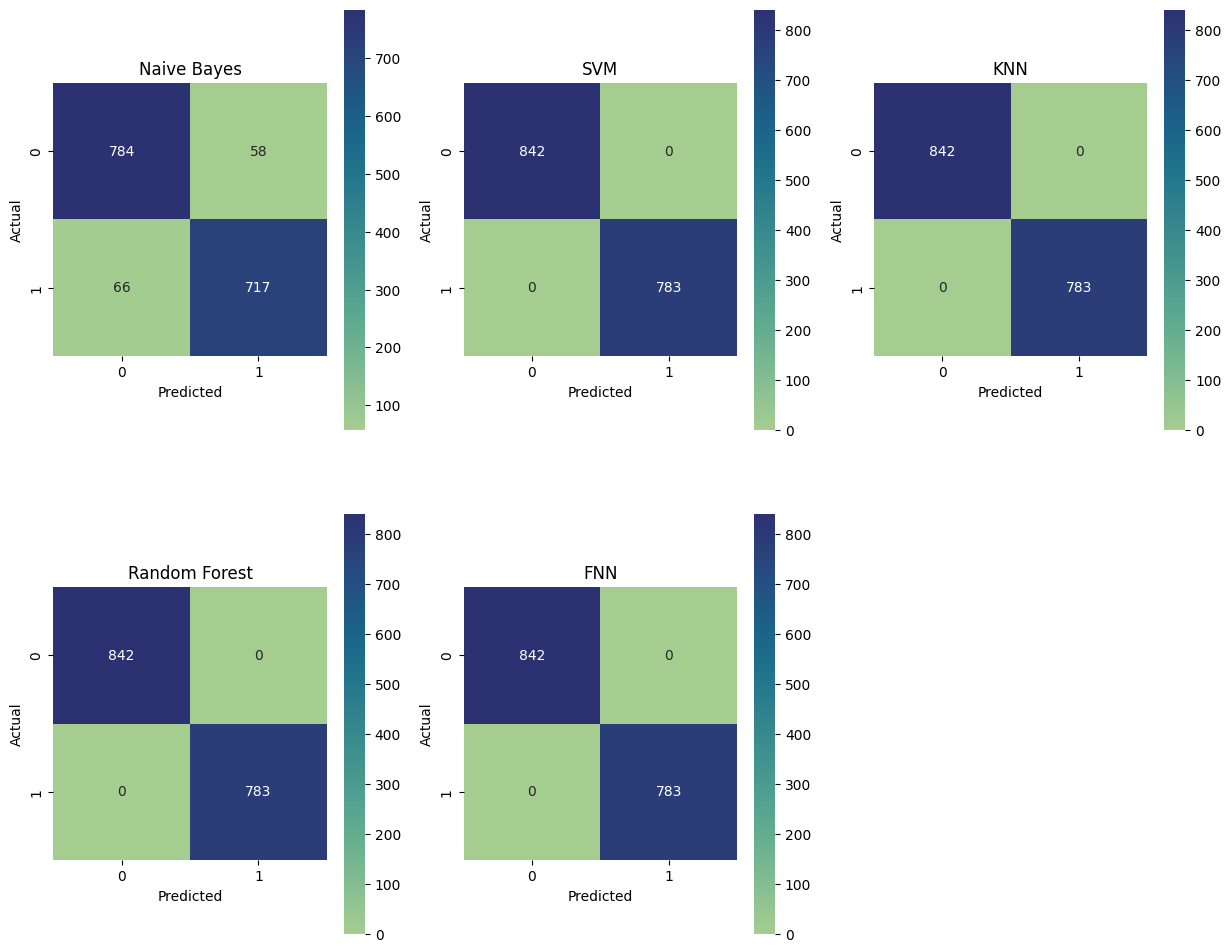

In [ ]:
#PLOT CONFUSION MATRIX

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 12))

models = list(results.keys())

for i, model in enumerate(models, 1):
    cm = results[model]['confusion_matrix']
    plt.subplot(2, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='crest',square=True)
    plt.title(f"{model}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")


In [ ]:
#CLASSIFICATION REPORT

from sklearn.metrics import classification_report

print("\n--- Naive Bayes ---")
print(classification_report(y_test, y_pred_nb))

print("\n--- SVM ---")
print(classification_report(y_test, y_pred_svm))

print("\n--- KNN ---")
print(classification_report(y_test, y_pred_knn))

print("\n--- Random Forest ---")
print(classification_report(y_test, y_pred_rf))

print("\n--- FNN ---")
print(classification_report(y_test, y_pred_nn))
print("\n")


--- Naive Bayes ---
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       842
           1       0.93      0.92      0.92       783

    accuracy                           0.92      1625
   macro avg       0.92      0.92      0.92      1625
weighted avg       0.92      0.92      0.92      1625


--- SVM ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625


--- KNN ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00    

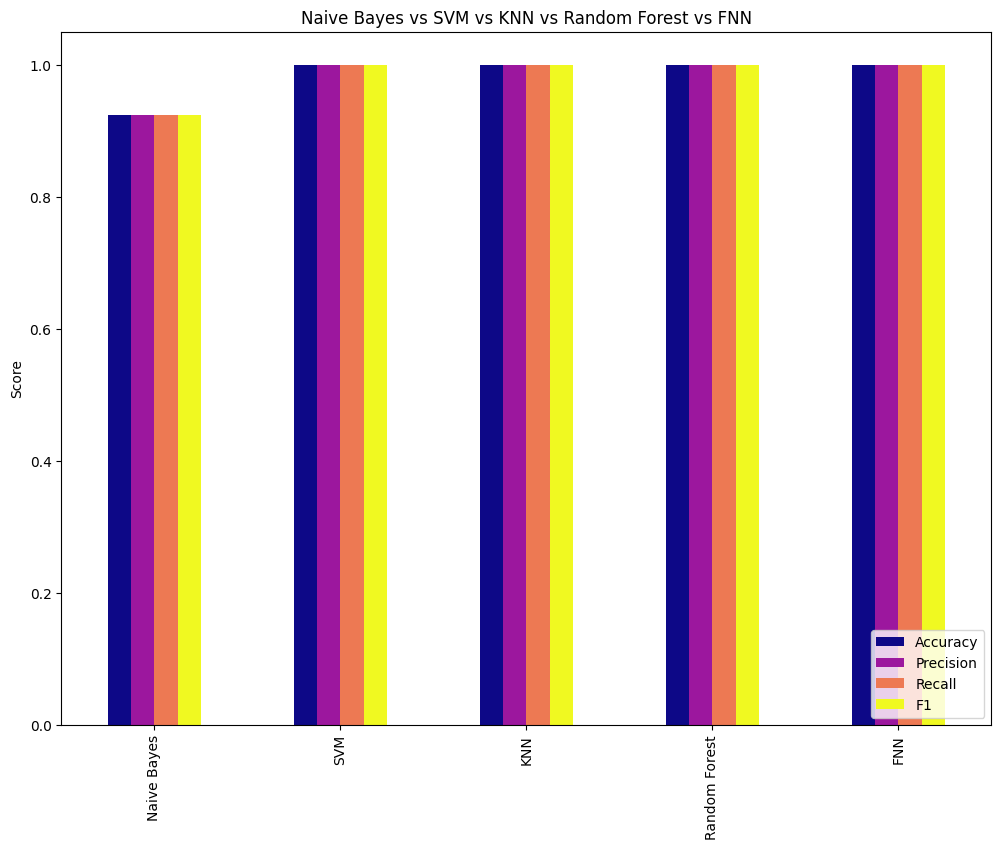

In [ ]:
#COMPARE MODEL PERFORMANCE
data = {}
for model in results:
    data[model] = {
        'Accuracy': results[model]['accuracy'],
        'Precision': results[model]['precision'],
        'Recall': results[model]['recall'],
        'F1': results[model]['f1']
    }

metrics_df = pd.DataFrame(data).T

metrics_df.plot(kind='bar', figsize=(12,9), colormap='plasma')
plt.title("Naive Bayes vs SVM vs KNN vs Random Forest vs FNN")
plt.ylabel("Score")
plt.legend(loc='lower right')
plt.show()


In [ ]:
data

{'Naive Bayes': {'Accuracy': 0.9236923076923077,
  'Precision': 0.9237571157495257,
  'Recall': 0.923412600904615,
  'F1': 0.9235623655228713},
 'SVM': {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0},
 'KNN': {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0},
 'Random Forest': {'Accuracy': 1.0,
  'Precision': 1.0,
  'Recall': 1.0,
  'F1': 1.0},
 'FNN': {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}}

#**FIT & CHECK MODEL PERFORMANCE FOR DROPPED DATASET**

In [ ]:
#FIT NAIVE BAYES

# Create model
nb = GaussianNB()

# Train
nb.fit(X_train_dropped_balanced, y_train_dropped_balanced)

# Predict
y_pred_dropped_nb = nb.predict(X_test_dropped)

In [ ]:
#FIT SUPPORT VECTOR MACHINE

# Create model
svm = SVC(kernel='rbf', random_state=1)

# Train
svm.fit(X_train_dropped_scaled, y_train_dropped_balanced)

# Predict
y_pred_dropped_svm = svm.predict(X_test_dropped_scaled)

In [ ]:
#FIT KNN & RANDOM FOREST


# Initialize models
knn_dropped = KNeighborsClassifier(n_neighbors=3)
rf_dropped = RandomForestClassifier(n_estimators=100, random_state=1)

# Fit models
knn_dropped.fit(X_train_dropped_scaled, y_train_dropped_balanced )
rf_dropped.fit(X_train_dropped_scaled, y_train_dropped_balanced )

# Predictions
y_pred_dropped_knn = knn_dropped.predict(X_test_dropped_scaled)
y_pred_dropped_rf = rf_dropped.predict(X_test_dropped_scaled)


In [ ]:
#FIT FEEDFORWARD NEURAL NETWORK

# Create model
nn = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # Two hidden layers
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=1
)

# Train
nn.fit(X_train_dropped_scaled, y_train_dropped_balanced)

# Predict
y_pred_dropped_nn = nn.predict(X_test_dropped_scaled)

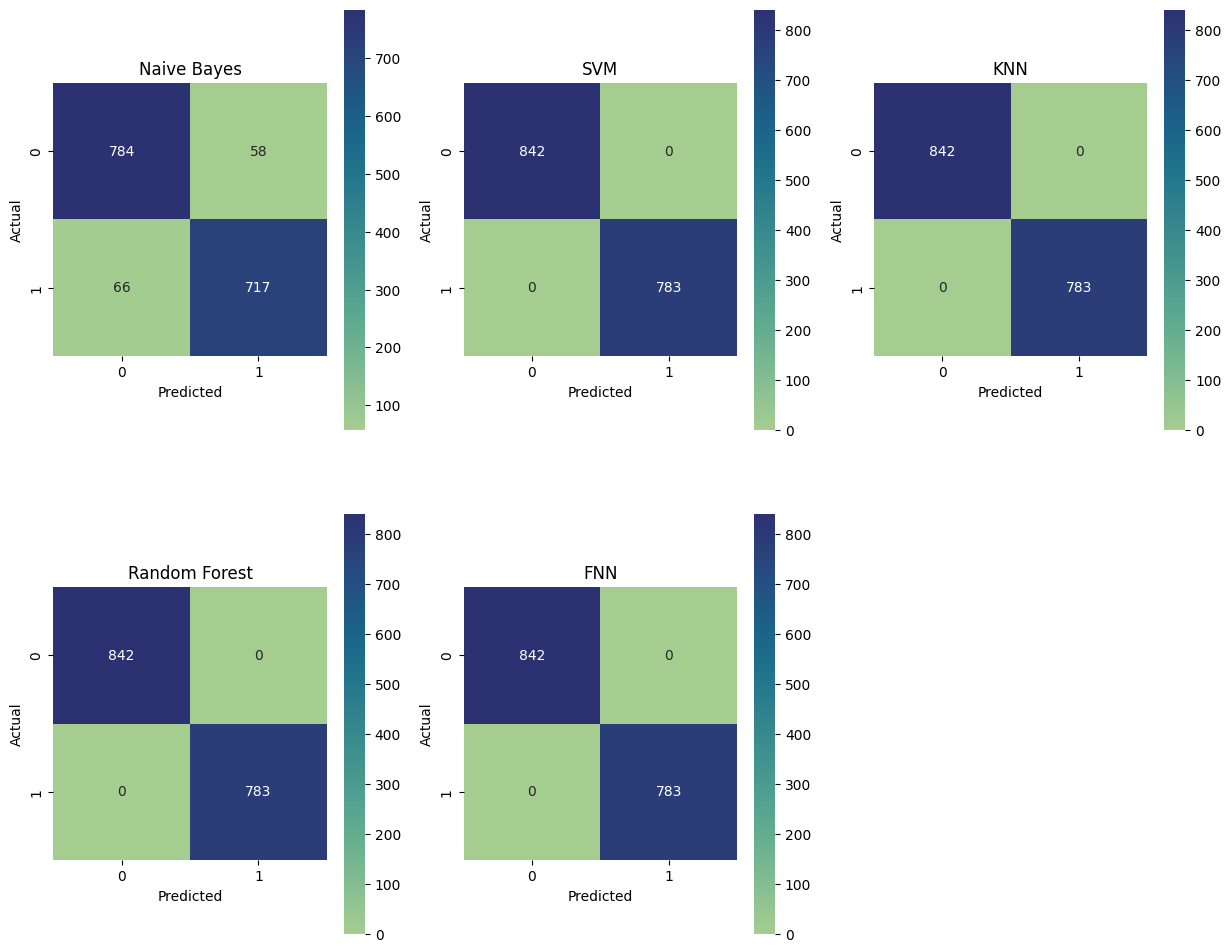

In [ ]:
#PLOT CONFUSION MATRIX

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 12))

models = list(results.keys())

for i, model in enumerate(models, 1):
    cm = results[model]['confusion_matrix']
    plt.subplot(2, 3, i)  # adjust if you have fewer/more models
    sns.heatmap(cm, annot=True, fmt='d', cmap='crest',square=True)
    plt.title(f"{model}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")


In [ ]:
#CLASSIFICAYION REPORT
print("\n--- Naive Bayes ---")
print(classification_report(y_test_dropped, y_pred_dropped_nb))

print("\n--- SVM ---")
print(classification_report(y_test_dropped, y_pred_dropped_svm))

print("\n--- KNN ---")
print(classification_report(y_test_dropped, y_pred_dropped_knn))

print("\n--- Random Forest ---")
print(classification_report(y_test_dropped, y_pred_dropped_rf))

print("\n--- FNN ---")
print(classification_report(y_test_dropped, y_pred_dropped_nn))
print("\n")


--- Naive Bayes ---
              precision    recall  f1-score   support

           0       0.69      0.98      0.81       698
           1       0.90      0.28      0.43       431

    accuracy                           0.71      1129
   macro avg       0.80      0.63      0.62      1129
weighted avg       0.77      0.71      0.66      1129


--- SVM ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       698
           1       1.00      1.00      1.00       431

    accuracy                           1.00      1129
   macro avg       1.00      1.00      1.00      1129
weighted avg       1.00      1.00      1.00      1129


--- KNN ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       698
           1       1.00      1.00      1.00       431

    accuracy                           1.00      1129
   macro avg       1.00      1.00      1.00      1129
weighted avg       1.00    

In [ ]:
#EVALUATION FUNCTION

def evaluate_model(y_true_dropped, y_pred_dropped, model_name):
    acc = accuracy_score(y_true_dropped, y_pred_dropped)
    prec = precision_score(y_true_dropped, y_pred_dropped,average='macro')
    rec = recall_score(y_true_dropped, y_pred_dropped,average='macro')
    f1 = f1_score(y_true_dropped, y_pred_dropped,average='macro')

    # Calculate confusion matrix
    cm = confusion_matrix(y_true_dropped, y_pred_dropped)

    # Return metrics and confusion matrix
    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm
    }

In [ ]:
results_dropped = {}

results_dropped['Naive Bayes'] = evaluate_model(y_test_dropped, y_pred_dropped_nb, "Naive Bayes")
results_dropped['SVM'] = evaluate_model(y_test_dropped, y_pred_dropped_svm, "Support Vector Machine")
results_dropped['KNN'] = evaluate_model(y_test_dropped, y_pred_dropped_knn, "K-Nearest Neighbors")
results_dropped['Random Forest'] = evaluate_model(y_test_dropped, y_pred_dropped_rf, "Random Forest")
results_dropped['FNN'] = evaluate_model(y_test_dropped, y_pred_dropped_nn, "FNN")

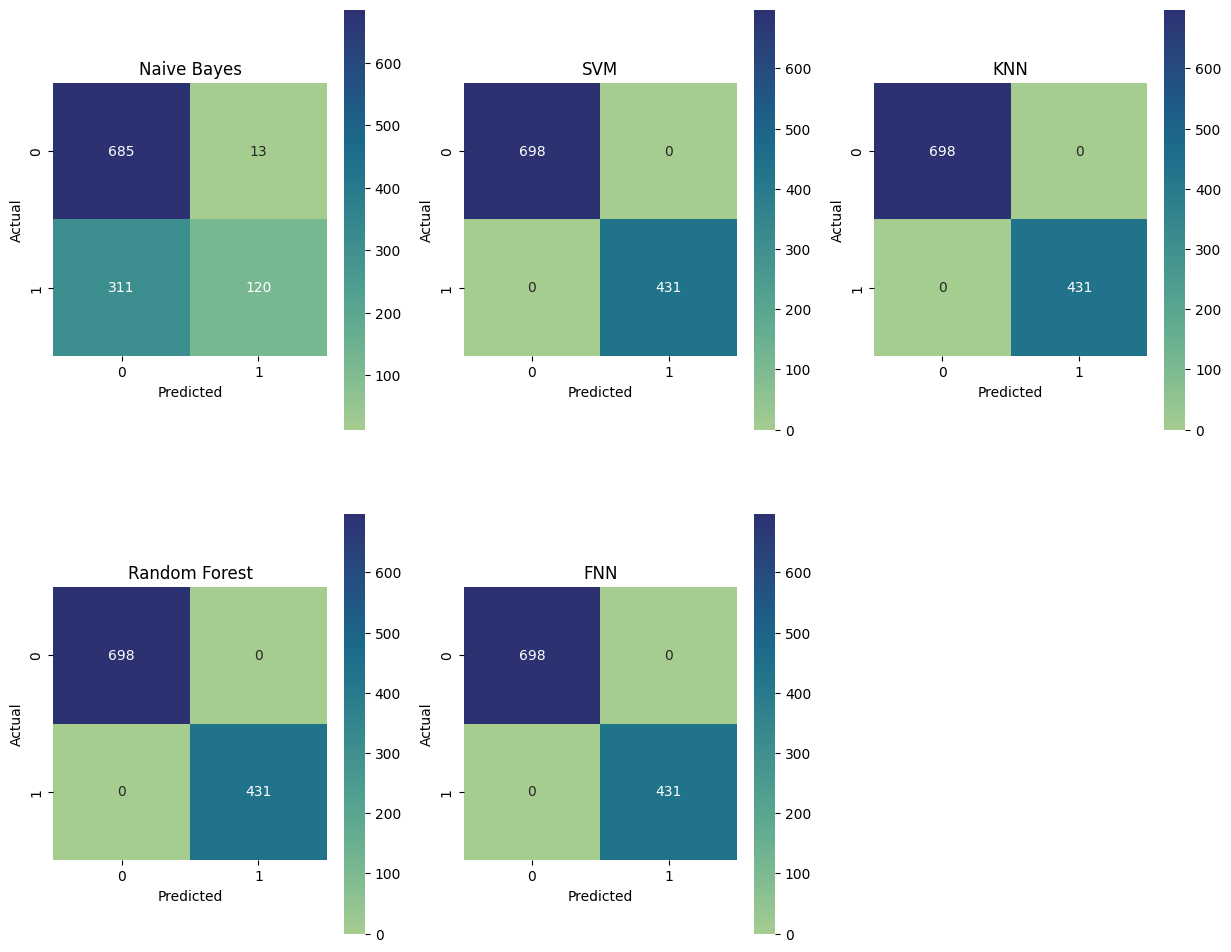

In [ ]:
#PLOT CONFUSION MATRIX

plt.figure(figsize=(15, 12))

models = list(results_dropped.keys())

for i, model in enumerate(models, 1):
    cm = results_dropped[model]['confusion_matrix']
    plt.subplot(2, 3, i)  # adjust if you have fewer/more models
    sns.heatmap(cm, annot=True, fmt='d', cmap='crest',square=True)
    plt.title(f"{model}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")


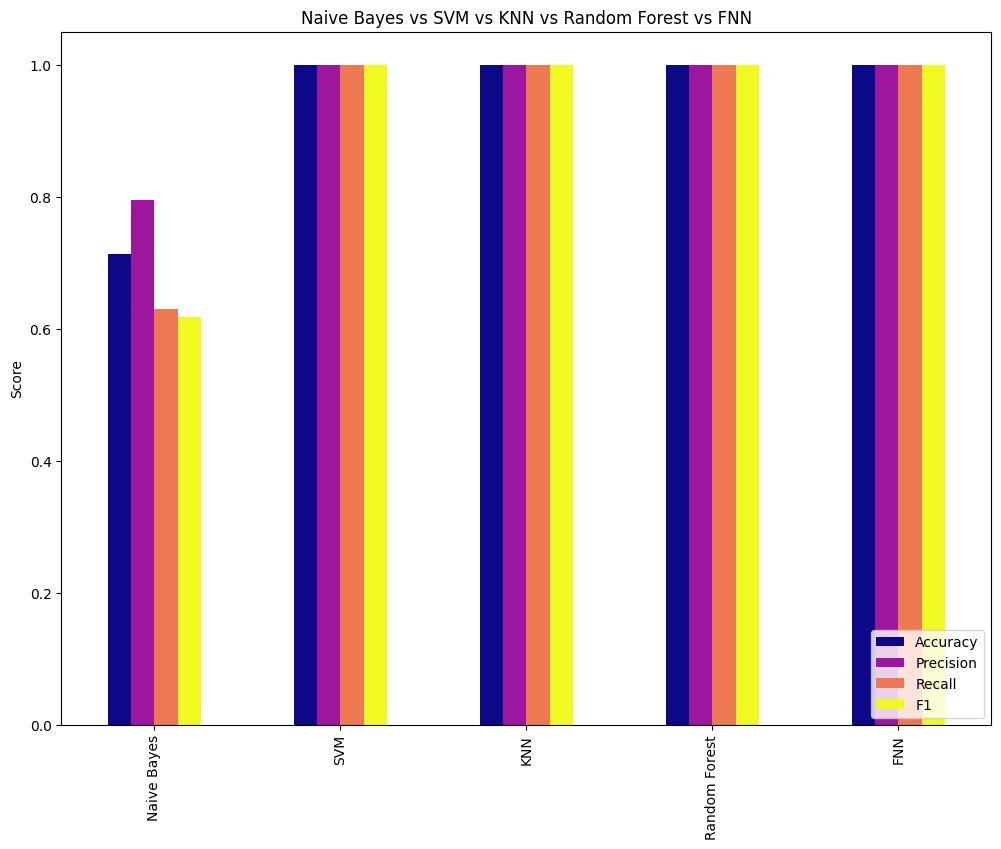

In [ ]:
#COMPARE MODEL PERFORMANCE(Dropped)
data_dropped = {}

for model in results_dropped:
    data_dropped[model] = {
        'Accuracy': results_dropped[model]['accuracy'],
        'Precision': results_dropped[model]['precision'],
        'Recall': results_dropped[model]['recall'],
        'F1': results_dropped[model]['f1']
    }

metrics_df_dropped = pd.DataFrame(data_dropped).T


metrics_df_dropped.plot(kind='bar', figsize=(12,9), colormap='plasma')
plt.title("Naive Bayes vs SVM vs KNN vs Random Forest vs FNN")
plt.ylabel("Score")
plt.legend(loc='lower right')
plt.show()

In [ ]:
results_dropped

{'Naive Bayes': {'model': 'Naive Bayes',
  'accuracy': 0.7130203720106288,
  'precision': 0.7950033215569043,
  'recall': 0.6298988159740458,
  'f1': 0.617134316360622,
  'confusion_matrix': array([[685,  13],
         [311, 120]])},
 'SVM': {'model': 'Support Vector Machine',
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'confusion_matrix': array([[698,   0],
         [  0, 431]])},
 'KNN': {'model': 'K-Nearest Neighbors',
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'confusion_matrix': array([[698,   0],
         [  0, 431]])},
 'Random Forest': {'model': 'Random Forest',
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'confusion_matrix': array([[698,   0],
         [  0, 431]])},
 'FNN': {'model': 'FNN',
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'confusion_matrix': array([[698,   0],
         [  0, 431]])}}